# Mary Ayisah-Eyeson MA21
# Build a model to predict which students are at risk of low academic performance. 
## What factors matter most, and how could a school counselor use this model for early intervention?
### Model: Gradient Boosting

In [1]:
#!pip install mlb
#!pip install xgboost

In [8]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier, plot_importance
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, root_mean_squared_error, roc_auc_score, confusion_matrix, precision_score,recall_score, f1_score

#show graphs in the code
%matplotlib inline

print("import Done")

import Done


# Load the data

In [51]:
educ_df = pd.read_csv('synthetic_education_20250901.txt',
                      sep=",",    # comma-separated
                      skipinitialspace=True,       # trims spaces after commas
                      engine='c',     # use an engine instead of python for faster running time
                      na_values=[""],              # treat empty fields as NaN
                      low_memory=False,            # better dtype inference
                      parse_dates=["enrollment_date"]  # auto-parse date column
                     )
educ_df.head(10)

,student_id,age,gender,gpa,sat_score,study_hours_week,attendance_rate,extracurricular_count,ap_courses_taken,family_income,...,class_size,tutoring_hours,library_visits_week,online_resource_hours,discipline_incidents,sleep_hours,stress_level,enrollment_date,academic_performance,college_readiness_score
0,ED0000001,21,Female,2.960000,1023.0,12.7,0.827,0,3,99588.76,...,22,1.6,2,2.7,0,6.7,3.4,2024-03-04,0,88.9
1,ED0000002,19,Male,4.778578,1125.0,12.6,0.500,0,2,26305.53,...,38,1.0,0,8.8,1,8.6,6.1,2022-03-13,0,53.3
2,ED0000003,22,Male,1.930000,1055.0,4.5,0.549,4,2,18487.34,...,33,1.4,1,3.9,0,6.2,8.3,2023-11-11,2,20.8
3,ED0000004,20,Female,3.170000,1181.0,8.2,0.739,5,1,41433.77,...,18,0.7,3,6.6,1,6.5,4.0,2022-06-02,0,85.3
4,ED0000005,19,Male,2.540000,944.0,11.6,0.547,3,3,57100.73,...,25,1.0,1,3.7,0,8.1,3.2,2024-04-14,1,52.5
5,ED0000006,19,Male,2.870000,1251.0,27.1,0.551,4,2,54449.14,...,22,1.3,2,4.7,2,6.6,5.9,2022-03-26,0,71.3
6,ED0000007,19,Male,4.576667,1138.0,23.5,0.887,5,3,51032.11,...,11,2.2,3,6.1,0,6.7,5.1,2022-12-08,0,100.0
7,ED0000008,20,Male,2.360000,981.0,13.7,0.685,2,2,34495.93,...,21,1.9,1,5.3,0,6.5,4.3,2022-07-24,1,46.1
8,ED0000009,19,Male,2.230000,1004.0,10.2,0.562,0,1,46261.34,...,25,0.5,0,2.8,1,7.4,4.2,2023-06-22,1,45.4
9,ED0000010,21,Female,1.730000,872.0,8.4,0.565,1,2,33244.30,...,28,1.6,0,1.7,0,7.4,4.9,2024-04-16,2,20.5


In [52]:
educ_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   student_id               300000 non-null  object        
 1   age                      300000 non-null  int64         
 2   gender                   300000 non-null  object        
 3   gpa                      300000 non-null  float64       
 4   sat_score                298556 non-null  float64       
 5   study_hours_week         298466 non-null  float64       
 6   attendance_rate          298526 non-null  float64       
 7   extracurricular_count    300000 non-null  int64         
 8   ap_courses_taken         300000 non-null  int64         
 9   family_income            298502 non-null  float64       
 10  parent_education         300000 non-null  object        
 11  school_type              300000 non-null  object        
 12  class_size      

In [53]:
educ_df.shape

(300000, 22)

In [54]:
# the summary of the data
educ_df.describe()

,age,gpa,sat_score,study_hours_week,attendance_rate,extracurricular_count,ap_courses_taken,family_income,class_size,tutoring_hours,library_visits_week,online_resource_hours,discipline_incidents,sleep_hours,stress_level,enrollment_date,academic_performance,college_readiness_score
count,300000.000000,300000.000000,298556.000000,298466.000000,298526.000000,300000.000000,300000.000000,2.985020e+05,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,298517.000000,298435.000000,300000,300000.000000,300000.000000
mean,20.003830,2.830406,1048.942192,13.758074,0.683322,2.293593,1.786177,4.238203e+04,25.854143,2.012369,1.405600,5.014177,1.189697,6.999507,5.009688,2023-05-16 16:12:45.504000,0.664243,60.562359
min,18.000000,0.500000,50.825881,1.300000,0.500000,0.000000,0.000000,1.500000e+04,10.000000,0.100000,0.000000,0.500000,0.000000,4.000000,1.000000,2022-01-01 00:00:00,0.000000,10.000000
25%,19.000000,2.350000,963.000000,8.700000,0.595000,1.000000,1.000000,2.606356e+04,21.000000,1.100000,0.000000,3.300000,0.000000,6.300000,3.900000,2022-09-07 00:00:00,0.000000,43.200000
50%,20.000000,2.810000,1049.000000,12.200000,0.690000,2.000000,2.000000,3.633875e+04,25.000000,1.600000,1.000000,4.500000,1.000000,7.000000,5.000000,2023-05-16 00:00:00,0.000000,60.900000
75%,21.000000,3.280000,1135.000000,17.000000,0.771000,3.000000,3.000000,5.061277e+04,29.000000,2.500000,2.000000,6.200000,1.000000,7.700000,6.100000,2024-01-23 00:00:00,1.000000,79.000000
max,29.000000,5.999701,1600.000000,119.863824,0.972000,10.000000,10.000000,2.998808e+06,149.000000,15.000000,11.000000,30.000000,39.000000,10.000000,10.000000,2024-09-29 00:00:00,2.000000,100.000000
std,1.417571,0.722048,129.100158,7.334128,0.112371,1.621819,1.530088,5.682102e+04,12.245573,1.412141,1.258685,2.507177,3.444872,1.041679,1.572718,NaN,0.797993,24.163209


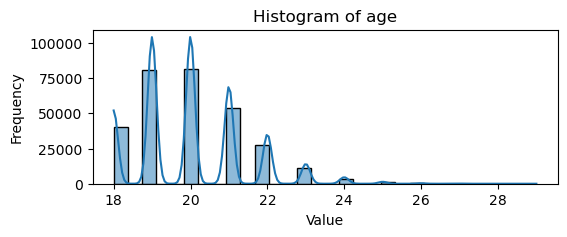

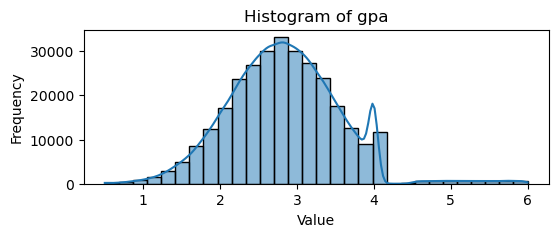

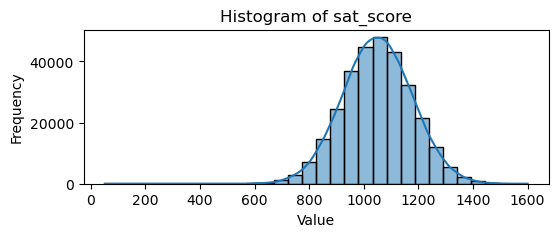

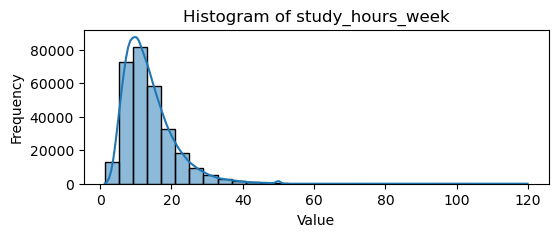

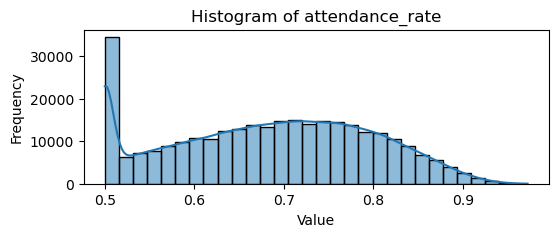

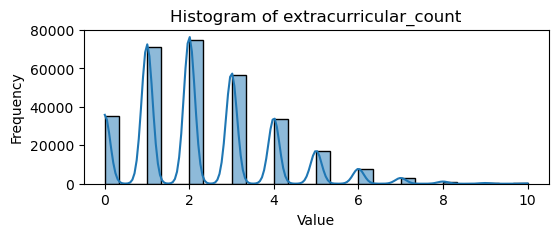

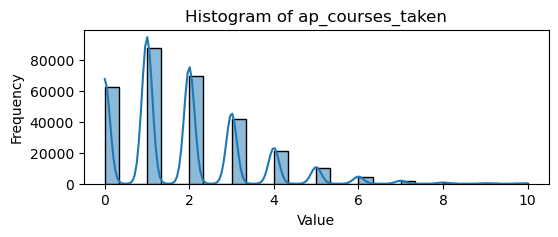

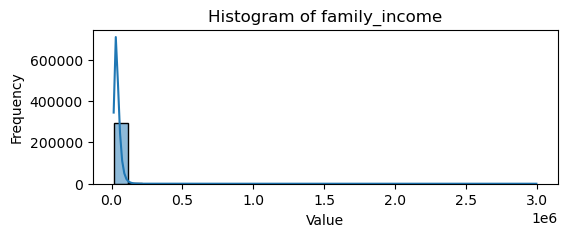

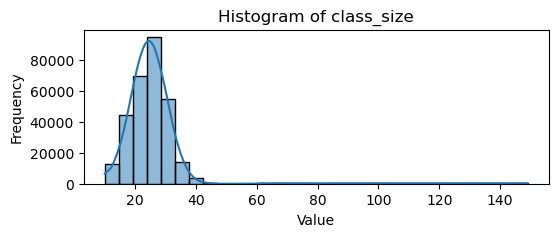

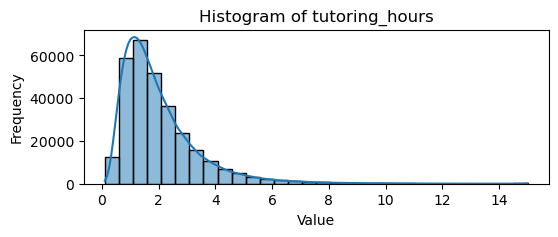

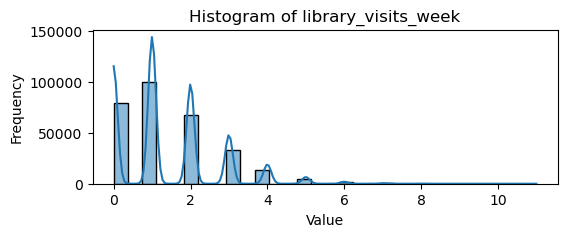

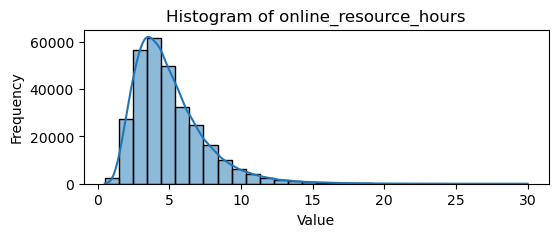

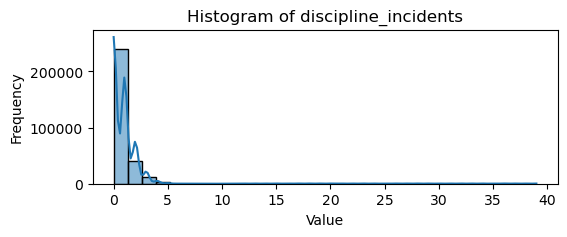

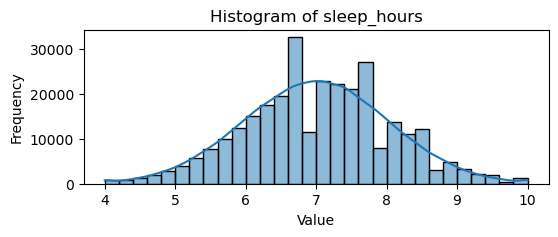

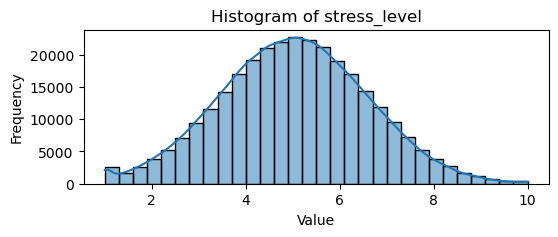

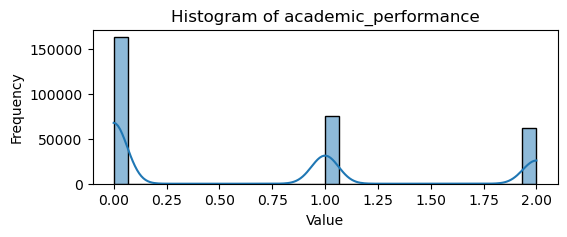

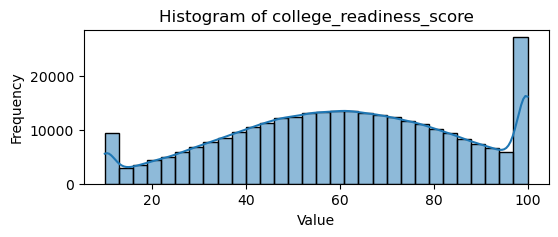

In [55]:
# plot a histogram of the features
#select numerical columns
num_cols = educ_df.select_dtypes(include=['float64', 'int64']).columns

#loop the columns
for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.histplot(data=educ_df, x=col, bins=30, kde=True) #visualize the distribution shape
    plt.title(f'Histogram of {col}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.show()

# Data Cleaning - handle missing values, duplicates, outliers (IQR)

In [56]:
# handle missing values
educ_df_clean = educ_df.isna().sum()
print(educ_df_clean)

student_id                    0
age                           0
gender                        0
gpa                           0
sat_score                  1444
study_hours_week           1534
attendance_rate            1474
extracurricular_count         0
ap_courses_taken              0
family_income              1498
parent_education              0
school_type                   0
class_size                    0
tutoring_hours                0
library_visits_week           0
online_resource_hours         0
discipline_incidents          0
sleep_hours                1483
stress_level               1565
enrollment_date               0
academic_performance          0
college_readiness_score       0
dtype: int64


In [57]:
#remove duplicates
educ_df_clean = educ_df.dropna(subset=[
    "student_id",
    "attendance_rate",
    "study_hours_week",
    "family_income",
    "sleep_hours",
    "stress_level",
    "discipline_incidents",
    "academic_performance"
])

# write a print statement to see if it was removed
print('Cleaned data is :', educ_df_clean.head())

Cleaned data is :   student_id  age  gender       gpa  sat_score  study_hours_week  \
0  ED0000001   21  Female  2.960000     1023.0              12.7   
1  ED0000002   19    Male  4.778578     1125.0              12.6   
2  ED0000003   22    Male  1.930000     1055.0               4.5   
3  ED0000004   20  Female  3.170000     1181.0               8.2   
4  ED0000005   19    Male  2.540000      944.0              11.6   

   attendance_rate  extracurricular_count  ap_courses_taken  family_income  \
0            0.827                      0                 3       99588.76   
1            0.500                      0                 2       26305.53   
2            0.549                      4                 2       18487.34   
3            0.739                      5                 1       41433.77   
4            0.547                      3                 3       57100.73   

   ... class_size tutoring_hours  library_visits_week  online_resource_hours  \
0  ...         22       

In [58]:
# double check the cleaning process
print(educ_df_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 292446 entries, 0 to 299999
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   student_id               292446 non-null  object        
 1   age                      292446 non-null  int64         
 2   gender                   292446 non-null  object        
 3   gpa                      292446 non-null  float64       
 4   sat_score                291002 non-null  float64       
 5   study_hours_week         292446 non-null  float64       
 6   attendance_rate          292446 non-null  float64       
 7   extracurricular_count    292446 non-null  int64         
 8   ap_courses_taken         292446 non-null  int64         
 9   family_income            292446 non-null  float64       
 10  parent_education         292446 non-null  object        
 11  school_type              292446 non-null  object        
 12  class_size           

In [59]:
# imputations
columns_needed = [
    "student_id",
    "attendance_rate",
    "study_hours_week",
    "family_income",
    "sleep_hours",
    "stress_level",
    "discipline_incidents",
    "academic_performance"
]
educ_df_clean = educ_df[columns_needed].copy()

print('data saved', educ_df_clean)

data saved        student_id  attendance_rate  study_hours_week  family_income  \
0       ED0000001            0.827              12.7       99588.76   
1       ED0000002            0.500              12.6       26305.53   
2       ED0000003            0.549               4.5       18487.34   
3       ED0000004            0.739               8.2       41433.77   
4       ED0000005            0.547              11.6       57100.73   
...           ...              ...               ...            ...   
299995  ED0299996            0.861              18.0       86864.56   
299996  ED0299997            0.697              11.2       59707.78   
299997  ED0299998            0.712              15.4       32861.06   
299998  ED0299999            0.666               7.9       22462.32   
299999  ED0300000            0.669               4.4       24773.89   

        sleep_hours  stress_level  discipline_incidents  academic_performance  
0               6.7           3.4                     0 

## Outliers

In [60]:
# Find number of outliers in data
def find_outliers_iqr(df, column, factor=1.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return df[(df[column] < lower) | (df[column] > upper)]

outlier_columns = [
    "attendance_rate",
    "study_hours_week",
    "family_income",
    "sleep_hours",
    "stress_level",
    "discipline_incidents",
    "academic_performance"
]

for col in outlier_columns:
    outliers = find_outliers_iqr(educ_df_clean, col)
    print(f"{col}: {len(outliers)} outliers")

attendance_rate: 0 outliers
study_hours_week: 10706 outliers
family_income: 11259 outliers
sleep_hours: 1832 outliers
stress_level: 872 outliers
discipline_incidents: 19943 outliers
academic_performance: 0 outliers


In [63]:
# drop outliers
for col in outlier_columns:
    outliers = find_outliers_iqr(educ_df_clean, col)
    educ_df_clean = educ_df_clean.drop(outliers.index)

print(educ_df_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 245434 entries, 1 to 299999
Data columns (total 8 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   student_id            245434 non-null  object 
 1   attendance_rate       245434 non-null  float64
 2   study_hours_week      245434 non-null  float64
 3   family_income         245434 non-null  float64
 4   sleep_hours           245434 non-null  float64
 5   stress_level          245434 non-null  float64
 6   discipline_incidents  245434 non-null  int64  
 7   academic_performance  245434 non-null  int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 16.9+ MB
None


In [64]:
# drop the remainder nans
educ_df_clean = educ_df_clean.dropna()
#print(educ_df_clean.info())
print('final row count: ', len(educ_df_clean))

final row count:  245434


# EXPLORATORY DATA ANALYSIS

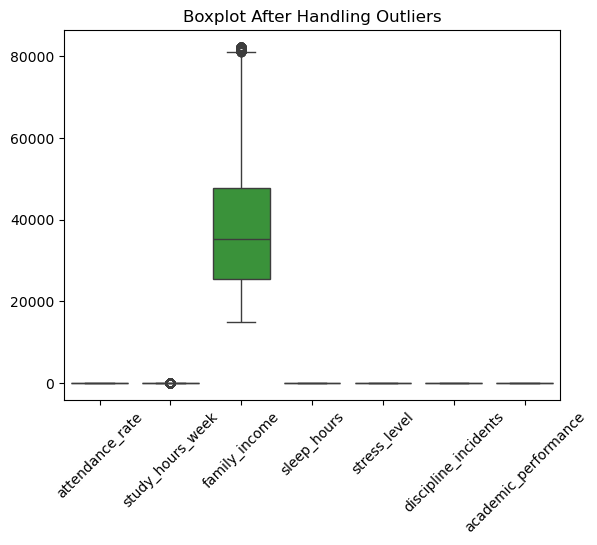

In [65]:
# Verify Result after outliers
#plot all numerical columns in outliers
sns.boxplot(data=educ_df_clean.select_dtypes(include=['number']))
plt.xticks(rotation=45) # rotates labels so they do not overlap
plt.title('Boxplot After Handling Outliers')
plt.show()

## feature engineering

In [66]:
# feature engineering - binning the family income
#predefine the thresholds on the domain
hours_bins = [0, 5, 10, 20, 100]
hours_labels = ['Low', 'Moderate', 'High', 'Extreme']
educ_df_clean['study_h_category'] = pd.cut(educ_df_clean['study_hours_week'], 
                                           bins=hours_bins, 
                                           labels=hours_labels,
                                          include_lowest=True #ensure that the lowest 0 is included)
                                          )

# family_income binning
# split into 4 and let data define the buckets
# bottom 25%, 50%, 75%, 100%-Extremely rich
educ_df_clean['Income_quartile'] = pd.qcut(
    educ_df_clean['family_income'], 
    q=4, 
    labels=['Q1', 'Q2', 'Q3', 'Q4'])

In [67]:
# interactions
educ_df_clean['Effort Levels'] = educ_df_clean['study_hours_week'] * educ_df_clean['attendance_rate']

In [69]:
# One-hot encode the categorical data created
# ordinal encode- preserve the rank for the hours_labels
mapping = {'Low': 1, 'Moderate': 2, 'High': 3, 'Extreme': 4}
educ_df_clean['study_h_category'] = educ_df_clean['study_h_category'].map(mapping)

#one-hot encode incone_quartile and drop the first column Q1
educ_df_clean = pd.get_dummies(educ_df_clean, columns=['Income_quartile'], drop_first=True)
print(educ_df_clean.columns)

Index(['student_id', 'attendance_rate', 'study_hours_week', 'family_income',
       'sleep_hours', 'stress_level', 'discipline_incidents',
       'academic_performance', 'study_h_category', 'Effort Levels',
       'Income_quartile_Q2', 'Income_quartile_Q3', 'Income_quartile_Q4'],
      dtype='object')


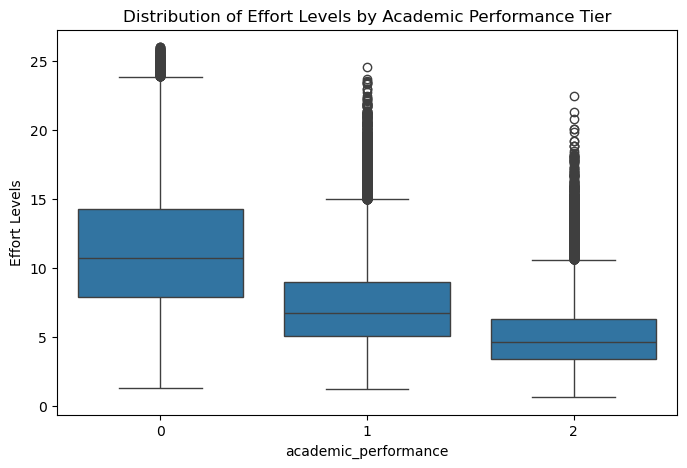

In [70]:
# correlation check
# See how Effort Levels are distributed across the three performance tiers
plt.figure(figsize=(8, 5))
sns.boxplot(x='academic_performance', y='Effort Levels', data=educ_df_clean)
plt.title('Distribution of Effort Levels by Academic Performance Tier')
plt.show()

# Train-Test Split

In [71]:
#spilt the data into 54/26/20
y = educ_df_clean['academic_performance']

X = educ_df_clean.drop(columns=['academic_performance', 'student_id'])
# split test data
X_temptest, X_test, y_temptest, y_test= train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

#split train and validation
X_train, X_valid, y_train, y_valid = train_test_split(X_temptest, y_temptest, test_size=0.26, random_state=42, stratify=y_temptest)

# Model Selection and Training

In [72]:
#since I am using gradient boosting, initialize the system
model = XGBClassifier(enable_categorical=True, tree_method="hist")

#fit model so it learns
model.fit(X_train, y_train)

print("Probabilities for the first 5 validation samples: ")
print(model.predict_proba(X_valid[:5]))

Probabilities for the first 5 validation samples: 
[[9.7401345e-01 2.5894372e-02 9.2196446e-05]
 [8.4349740e-01 1.3176137e-01 2.4741203e-02]
 [1.4395659e-01 3.2575777e-01 5.3028566e-01]
 [1.2746637e-01 5.0787187e-01 3.6466181e-01]
 [2.3575847e-01 2.4795054e-01 5.1629102e-01]]


In [73]:
print(y_train.value_counts(normalize=True))

academic_performance
0    0.523855
1    0.265912
2    0.210233
Name: proportion, dtype: float64


# Hyperparameter

In [74]:
param_grid = {
    'n_estimators': [100, 200, 300], # number of trees
    'max_depth': [None, 10, 20, 30], # depth and complexity of each tree
    'learning_rate': [0.01,0.05,0.1], # the ETA or how fast the model learns
    'colsample_bytree': [0.7,0.8,0.9], # the percentage of the columns randomly used
    'subsample': [0.7,0.8,0.9] # the percentage of the rows randomly used
}

# Initialize the search
random_search = RandomizedSearchCV(
    estimator=model, 
    param_distributions=param_grid, 
    n_iter=10, # Number of combinations to try
    cv=3,      # 3-fold cross-validation
    scoring='f1_weighted', # Excellent for multiclass
    random_state=42,
    n_jobs=-1  # Use all computer processors
)

# Fit the search to the training data
random_search.fit(X_train, y_train)

# Get the best parameters
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}")

Best Parameters: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': None, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best Score: 0.6344571234569757


# Model Evaluation

In [75]:
# evaluation metrics
y_pred = random_search.predict(X_test)

print('Accuracy: ', accuracy_score(y_test, y_pred)) 
print('RMSE: ', np.sqrt(root_mean_squared_error(y_test, y_pred)))
print('Confusion Matrix: ', confusion_matrix(y_test, y_pred))

# Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].
print('Precision Score: ', precision_score(y_test, y_pred, average='weighted')) 
print('Recall Score: ', recall_score(y_test, y_pred, average='weighted')) 
print('F1 Score: ', f1_score(y_test, y_pred, average='weighted')) 

Accuracy:  0.6543280298245971
RMSE:  0.8388029433972015
Confusion Matrix:  [[22100  2785   829]
 [ 6246  4019  2788]
 [ 1615  2705  6000]]
Precision Score:  0.6299586847873327
Recall Score:  0.6543280298245971
F1 Score:  0.637155091026158


# Model Importance

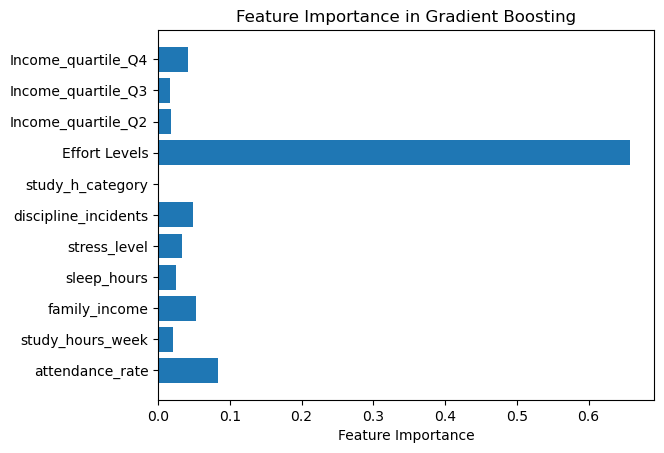

In [76]:
importance = model.feature_importances_
plt.barh(X.columns, importance)
plt.xlabel("Feature Importance")
plt.title("Feature Importance in Gradient Boosting")
plt.show()

In [77]:
# cross validation
scores = cross_val_score(model, X, y, cv=3)
print("Cross_Val_Accuracy: ", scores.mean())

Cross_Val_Accuracy:  0.6487976380286052


# Model Diagnostics

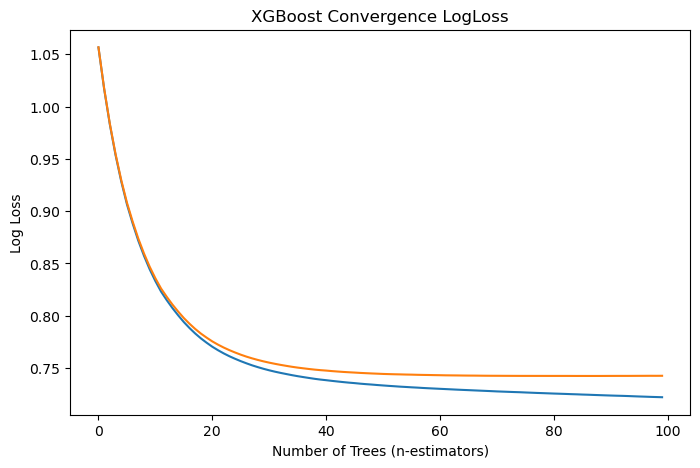

In [78]:
#convergence notes, variable importance and partial dependence
#convergence notes
best_model = random_search.best_estimator_
evaluation_set = [(X_train, y_train), (X_valid, y_valid)]

best_model.fit(
    X_train, 
    y_train, 
    eval_set=evaluation_set, 
    verbose=False #keeps the output clean
)
#retrieve the results
results = best_model.evals_result()

#plot the results
plt.figure(figsize=(8,5))
plt.plot(results['validation_0']['mlogloss'], label='Train')
plt.plot(results['validation_1']['mlogloss'], label='Valid')
plt.title('XGBoost Convergence LogLoss')
plt.xlabel('Number of Trees (n-estimators)')
plt.ylabel('Log Loss')
plt.show()

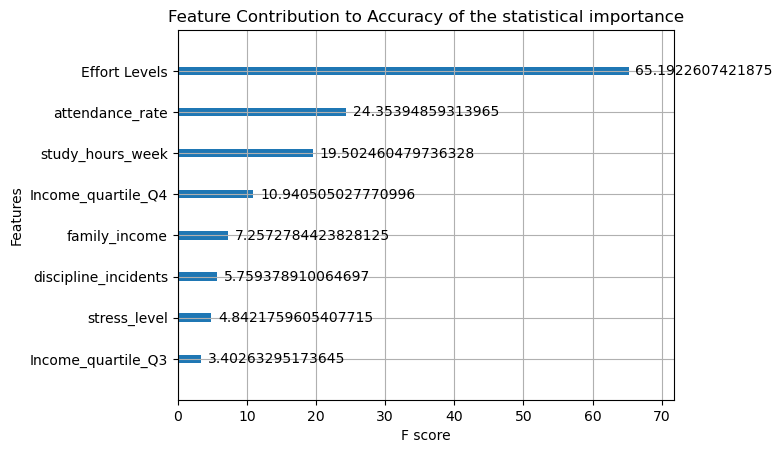

In [79]:
#variable importance
plot_importance(best_model, importance_type='gain', max_num_features=8)
plt.title("Feature Contribution to Accuracy of the statistical importance")
plt.show()

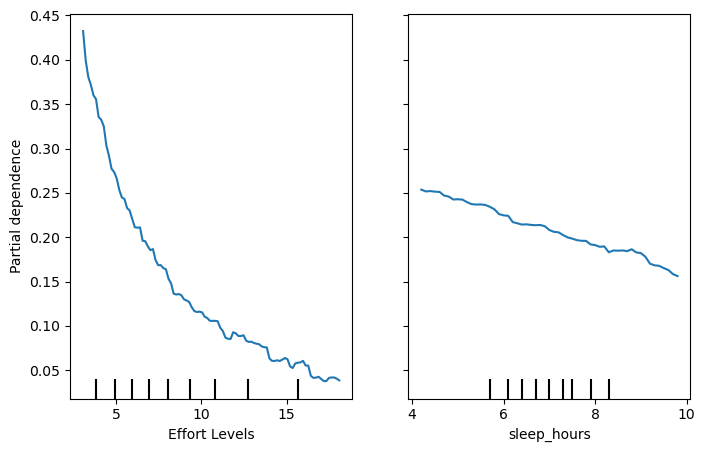

In [84]:
fig, ax = plt.subplots(figsize=(8,5))
PartialDependenceDisplay.from_estimator(best_model, X_train, features=['Effort Levels', 'sleep_hours'], 
                                        # effort_levels is a combination of study_h_week and attendance_rate,
                                       target=2, ax=ax)
plt.show()

In [85]:
# ROC-AUC
#probabilities for each class
y_probab = best_model.predict_proba(X_test)

# apply a threshold to the poor class. threshold 0.30
#if proba is > 30%, label as poor
y_threshold = np.where(
    y_probab[:, 0] > 0.30, 0, best_model.predict(X_test))
auc_score = roc_auc_score(y_test, y_probab, multi_class= 'ovr', average='weighted')

print('Confusion Matrix: ', confusion_matrix(y_test, y_threshold)) 
print('Weighted AUC_ROC Score: ', auc_score)

Confusion Matrix:  [[23693  1192   829]
 [ 8192  2073  2788]
 [ 2652  1668  6000]]
Weighted AUC_ROC Score:  0.816923768373038
